*(Repo layout 2026-09: this notebook lives under `analysis/`. Prefer `01_MetricsAndROC.ipynb` for the slim entry point; batch CLI is `analyze_outputs.py`. Outputs → `/exp/sbnd/data/users/munjung/anomaly-detection/{figures,roc_curves}`.)*

# Analyze diffusion inference outputs

Supports pickles from both `run_ddim2ddim_inference` and `run_mixed_diffusion_inference`.

- Load pickle bundles (`*_T{T}_{MODE}.pkl`) for **nominal** and **defect** runs.
- Inspect **individual patch images**: original / reconstruction / saliency (each patch `(H×W)`, no stitching).
- Project **|saliency|** along one axis (**projection**) with a scalar **threshold**.
- **ROC curve** + **efficiency × purity** (file-level scores = max statistic over patches inside each bundle).

## Paths, timestep, and mode

Adjust `RUN_NOMINALDIR`, `RUN_DEFECTSDIR`, `T`, and `MODE` before running. **Run cells in order** (ROC cell uses helpers from above).

- `MODE = "ddim2ddim"` → `run_ddim2ddim_inference.py` outputs (`*_T{T}_ddim2ddim.pkl`)
- `MODE = "rand2ddim"` / `"rand2ddpm"` / `"ddpm2ddpm"` / `"ddim2ddpm"` → `run_mixed_diffusion_inference.py --mode {MODE}` outputs

Pickles must contain integer patch keys plus a `__{MODE}_source__` metadata entry.

In [1]:
from __future__ import annotations

import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
stylefile = "presentation.mplstyle"
plt.style.use(stylefile)

import numpy as np
from sklearn.metrics import auc, roc_curve
from tqdm.auto import tqdm

# --- Configure ---
DEFECT_TYPE = "coh_noise"
MODEL_TYPE = "-anisotropic"
# MODEL_TYPE = ""

# Pickle mode tag — matches the script that produced the outputs:
#   "ddim2ddim"  → run_ddim2ddim_inference.py    (*_T{T}_ddim2ddim.pkl)
#   "rand2ddim"  → run_mixed_diffusion_inference.py --mode rand2ddim
#   "rand2ddpm"  → run_mixed_diffusion_inference.py --mode rand2ddpm
#   "ddpm2ddpm"  → run_mixed_diffusion_inference.py --mode ddpm2ddpm
#   "ddim2ddpm"  → run_mixed_diffusion_inference.py --mode ddim2ddpm

# MODE = "ddim2ddim"
# RUN_NOMINALDIR = Path(f"/scratch/7DayLifetime/munjung/ICARUS/plane1_healthy_outputs{MODEL_TYPE}")
# RUN_DEFECTSDIR = Path(f"/scratch/7DayLifetime/munjung/ICARUS/plane1_{DEFECT_TYPE}_outputs{MODEL_TYPE}")

MODE = "rand2ddpm"
RUN_NOMINALDIR = Path(f"/scratch/7DayLifetime/munjung/ICARUS/plane1_healthy_outputs-{MODE}{MODEL_TYPE}/mixed_{MODE}")
RUN_DEFECTSDIR = Path(f"/scratch/7DayLifetime/munjung/ICARUS/plane1_{DEFECT_TYPE}_outputs-{MODE}{MODEL_TYPE}/mixed_{MODE}")

T = 200  # Same T as filenames: *_T{T}_{MODE}.pkl

# Which axis we "integrate" for the 1D projection: axis=1 → one value per wire (column); axis=0 → per tick (row).
PROJECTION_AXIS = 0

# Example plots: which patch inside each pickle (sorted int keys)
PATCH_ORDINAL = 0

# Global ROC score per file: summarize saliency (max over patches of patch-level metric)
SCORE = "rms"  # "rms" sum of RMS per patch inside file | "proj_max_max" max of max(projected profile) across patches

RNG = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 110

# --- ROC saving ---
# Directory where ROC JSON files will be written.  Set to None to skip saving.
ROC_SAVE_DIR = Path("roc_curves")
# Short label that identifies this run in saved filenames and comparison plots.
ROC_LABEL = f"ICARUS_plane1_{DEFECT_TYPE}{MODEL_TYPE}"

print("Nominal", RUN_NOMINALDIR)
print("Defect ", RUN_DEFECTSDIR)
print("ROC save dir", ROC_SAVE_DIR)
print("ROC label", ROC_LABEL)


Nominal /scratch/7DayLifetime/munjung/ICARUS/plane1_healthy_outputs-rand2ddpm-anisotropic/mixed_rand2ddpm
Defect  /scratch/7DayLifetime/munjung/ICARUS/plane1_coh_noise_outputs-rand2ddpm-anisotropic/mixed_rand2ddpm
ROC save dir roc_curves
ROC label ICARUS_plane1_coh_noise-anisotropic


/home/munjung/.conda/envs/diffusion/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [341]:
# !ls /scratch/7DayLifetime/munjung/ICARUS/

In [342]:
def find_bundles(root: Path, T: int, mode: str = "ddim2ddim") -> list[Path]:
    """Find all pickle bundles for a given mode and timestep T."""
    return sorted(root.glob(f"*_T{T}_{mode}.pkl"))

def split_bundle(raw: dict) -> tuple[dict[int, dict], dict]:
    # Auto-detect any __<mode>_source__ metadata key
    trace_keys = [k for k in raw if isinstance(k, str) and k.startswith("__") and k.endswith("_source__")]
    meta = raw.get(trace_keys[0], {}) if trace_keys else {}
    per_patch = {k: v for k, v in raw.items() if isinstance(k, int)}
    return per_patch, meta

def infer_keys(sample_patch: dict) -> tuple[str, str]:
    # Reco key: any string key containing "-T" that is not "saliency-T..." or "original"
    reco = [
        k for k in sample_patch
        if isinstance(k, str) and "-T" in k and not k.startswith("saliency") and k != "original"
    ]
    sal = [k for k in sample_patch if isinstance(k, str) and k.startswith("saliency-T")]
    if len(reco) != 1 or len(sal) != 1:
        raise ValueError(
            f"Could not uniquely infer reconstruction keys from first patch "
            f"(found reco={reco}, saliency={sal})"
        )
    return reco[0], sal[0]

def load_bundle(path: Path) -> tuple[dict[int, dict], dict, str, str]:
    with path.open("rb") as fh:
        raw = pickle.load(fh)
    per_patch, trace = split_bundle(raw)
    if not per_patch:
        raise ValueError(f"No patch entries in {path}")
    ddim_k, sal_k = infer_keys(per_patch[next(iter(per_patch))])
    return per_patch, trace, ddim_k, sal_k

def arrays_for_patch(
    bundle_path: Path,
    ordinal: int = 0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict, int]:
    """Pick one patch by sorted key order (`ordinal`): no stitching."""
    per_patch, trace, ddim_k, sal_k = load_bundle(bundle_path)
    keys_sorted = sorted(per_patch.keys())
    if not keys_sorted:
        raise ValueError(bundle_path)
    key = keys_sorted[ordinal % len(keys_sorted)]
    p = per_patch[key]
    return (
        np.squeeze(p["original"]),
        np.squeeze(p[ddim_k]),
        np.squeeze(p[sal_k]),
        trace,
        key,
    )


Helpers above: `arrays_for_patch(path, PATCH_ORDINAL)` returns `(orig, reco, sal, trace dict, patch_key)` for a **single** `512×512` tile. `find_bundles(root, T, MODE)` locates `*_T{T}_{MODE}.pkl` files; reco/saliency keys and the trace key are auto-detected from the first patch.

## Example images

One **patch** per bundle (see `PATCH_ORDINAL`); no plane stitching.

Bundles: nominal=65 defect=30


/tmp/ipykernel_34626/1305685609.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


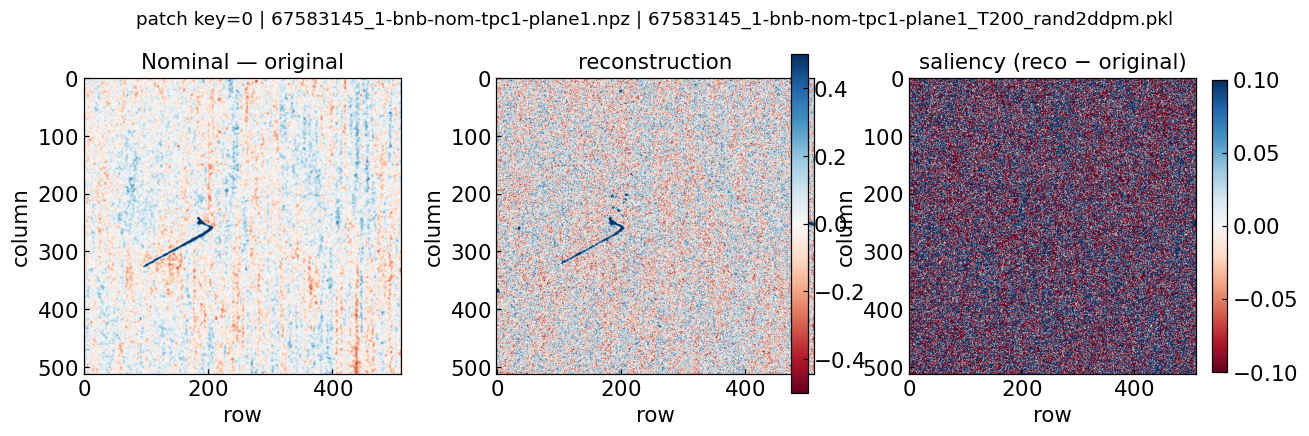

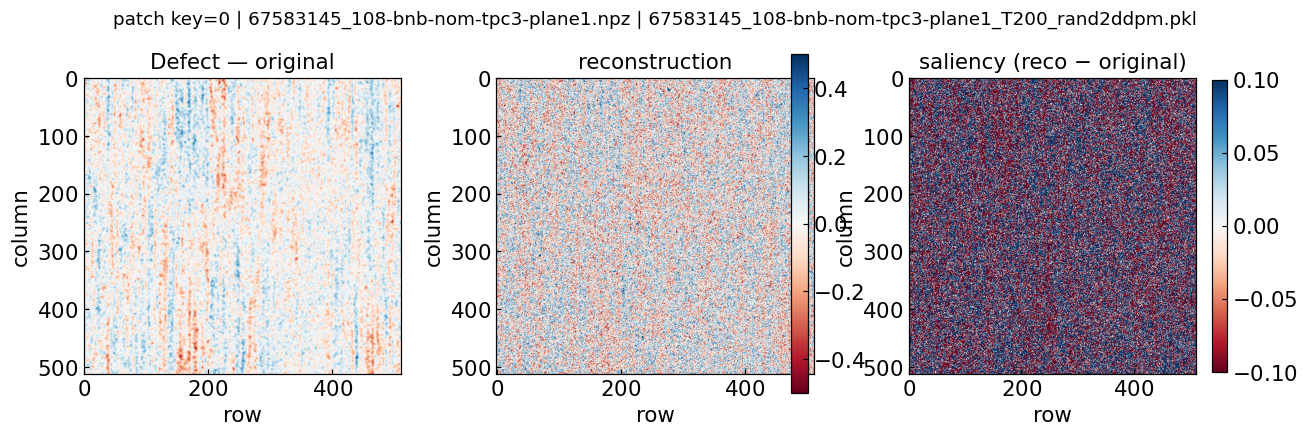

In [343]:
nom_pkls = find_bundles(RUN_NOMINALDIR, T, MODE)
def_pkls = find_bundles(RUN_DEFECTSDIR, T, MODE)
print(f"Bundles: nominal={len(nom_pkls)} defect={len(def_pkls)}")

if nom_pkls and def_pkls:
    ex_nom = RNG.choice(np.array(nom_pkls, dtype=object))
    ex_def = RNG.choice(np.array(def_pkls, dtype=object))

    for title, bp in [("Nominal", ex_nom), ("Defect", ex_def)]:
        orig, reco, sal, trace, pk = arrays_for_patch(bp, PATCH_ORDINAL)
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        im0 = ax[0].imshow(orig, aspect="auto", cmap="RdBu", vmin=-0.5, vmax=0.5)
        ax[0].set_title(title + " — original")
        ax[1].imshow(reco, aspect="auto", cmap="RdBu", vmin=-0.5, vmax=0.5)
        ax[1].set_title("reconstruction")
        im2 = ax[2].imshow(sal, aspect="auto", cmap="RdBu", vmin=-0.1, vmax=0.1)
        ax[2].set_title("saliency (reco − original)")
        for a in ax:
            a.set_xlabel("column" if PROJECTION_AXIS == 1 else "row")
            a.set_ylabel("row" if PROJECTION_AXIS == 1 else "column")
        plt.colorbar(im0, ax=ax[:2], fraction=0.046)
        plt.colorbar(im2, ax=ax[2], fraction=0.046)
        fn = trace.get("input_filename", bp.name)
        fig.suptitle(f"patch key={pk} | {fn} | {bp.name}")
        plt.tight_layout()
        plt.show()
else:
    print("Need at least one nominal + one defect bundle to plot examples")


## Projection along one axis

Pick **(|saliency|)** from **one patch** (`PATCH_ORDINAL`, first defect pickle) and collapse along `PROJECTION_AXIS`; threshold example uses the P95 of the projected profile.

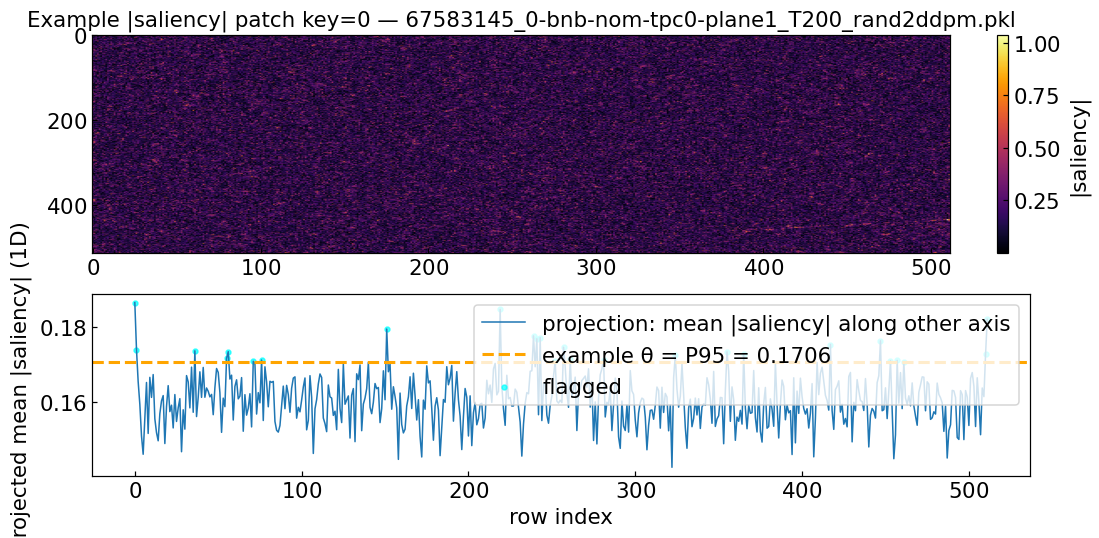

In [344]:
def projected_profile(abs_sal: np.ndarray, axis: int) -> np.ndarray:
    return np.mean(abs_sal, axis=axis)

if def_pkls:
    bp = Path(def_pkls[0])
    _, _, sal_example, trace_ex, pk = arrays_for_patch(bp, PATCH_ORDINAL)
    abs_s = np.abs(sal_example.astype(np.float64))
    proj = projected_profile(abs_s, PROJECTION_AXIS)
    thresh_plot = np.percentile(proj, 95)

    axes_label = (
        "column index"
        if PROJECTION_AXIS == 1
        else "row index"
    )
    flagged = proj >= thresh_plot

    fig, ax = plt.subplots(2, 1, figsize=(10, 5), gridspec_kw={"height_ratios": [1.2, 1]})
    im = ax[0].imshow(abs_s, aspect="auto", cmap="inferno")
    plt.colorbar(im, ax=ax[0], fraction=0.035, label="|saliency|")
    ax[0].set_title(f"Example |saliency| patch key={pk} — {bp.name}")

    xc = np.arange(proj.size)
    ax[1].plot(xc, proj, lw=1, label="projection: mean |saliency| along other axis")
    ax[1].axhline(thresh_plot, color="orange", ls="--", lw=2, label=f"example θ = P95 = {thresh_plot:.4g}")
    ax[1].scatter(xc[flagged], proj[flagged], c="cyan", s=10, alpha=0.7, label="flagged")
    ax[1].set_xlabel(axes_label)
    ax[1].set_ylabel("projected mean |saliency| (1D)")
    ax[1].legend(loc="upper right")
    plt.tight_layout()
    plt.show()


## File-level scores and ROC

**Label** `1` defect, `0` nominal. Each bundle gets one score = **max** over its patch-level metrics.

- **ROC** TPR vs FPR.
- **Efficiency × purity** as the score cut varies.

score defect: 100%|██████████| 30/30 [00:03<00:00,  8.59it/s]


n nominal patches 6480 n defect patches 2980


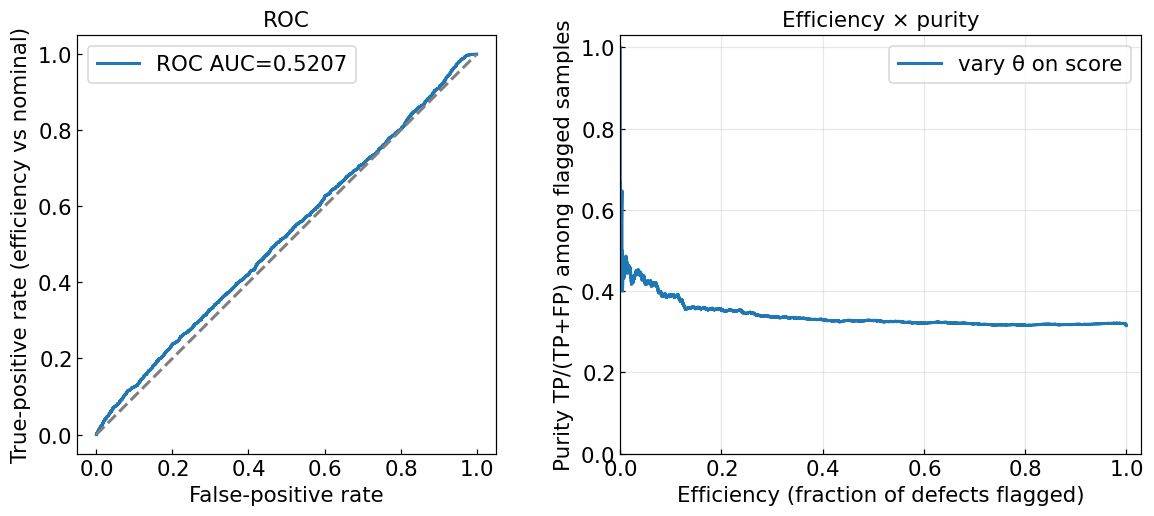

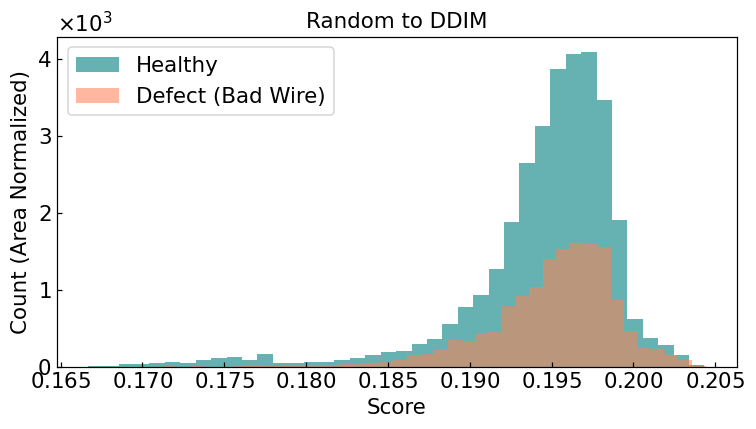

In [345]:


def bundle_patch_scores(bundle_path: Path, axis: int, score_mode: str) -> list[float]:
    """Return one score per patch inside this bundle."""
    per_patch, _, _, sal_k = load_bundle(bundle_path)
    patch_scores: list[float] = []
    for j in sorted(per_patch.keys()):
        sal = np.squeeze(per_patch[j][sal_k]).astype(np.float64)
        abs_s = np.abs(sal)
        if score_mode == "rms":
            patch_scores.append(float(np.sqrt(np.mean(abs_s**2))))
        elif score_mode == "proj_max_max":
            proj = projected_profile(abs_s, axis)
            patch_scores.append(float(np.max(proj)))
        else:
            raise ValueError(score_mode)
    return patch_scores


nom_scores = []
def_scores = []

for bp in tqdm(nom_pkls, desc="score nominal"):
    try:
        nom_scores.extend(bundle_patch_scores(bp, PROJECTION_AXIS, SCORE))
    except Exception as e:
        print("skip nominal", bp, e)

for bp in tqdm(def_pkls, desc="score defect"):
    try:
        def_scores.extend(bundle_patch_scores(bp, PROJECTION_AXIS, SCORE))
    except Exception as e:
        print("skip defect", bp, e)

nom_scores = np.asarray(nom_scores, dtype=float)
def_scores = np.asarray(def_scores, dtype=float)
# nom_scores = nom_scores[nom_scores <= 0.0045]
y = np.concatenate([np.zeros(len(nom_scores)), np.ones(len(def_scores))])
scores_all = np.concatenate([nom_scores, def_scores])

print(
    "n nominal patches", len(nom_scores),
    "n defect patches", len(def_scores),
)

if scores_all.size and np.unique(y).size >= 2:
    fpr, tpr, _ = roc_curve(y, scores_all)
    auc_val = auc(fpr, tpr)

    thresholds = np.sort(np.unique(np.concatenate(([scores_all.min() - 1e-6], scores_all, [scores_all.max() + 1e-6]))))
    eff, pur = [], []
    for th in thresholds[::-1]:
        pred = scores_all >= th
        tp = np.sum(pred & (y == 1))
        fp = np.sum(pred & (y == 0))
        tp_fn = tp + np.sum(~pred & (y == 1))
        eff.append(tp / tp_fn if tp_fn else np.nan)
        pur.append(tp / (tp + fp) if (tp + fp) else np.nan)

    eff = np.asarray(eff)
    pur = np.asarray(pur)

    fig, ax = plt.subplots(1, 2, figsize=(11, 4.8))
    ax[0].plot(fpr, tpr, lw=2, label=f"ROC AUC={auc_val:.4f}")
    ax[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
    ax[0].set_xlabel("False-positive rate")
    ax[0].set_ylabel("True-positive rate (efficiency vs nominal)")
    ax[0].set_title("ROC")
    ax[0].legend()
    ax[0].set_aspect("equal", adjustable="box")

    sel = ~(np.isnan(eff) | np.isnan(pur))
    ax[1].plot(eff[sel], pur[sel], lw=2, marker="", label="vary θ on score")
    ax[1].set_xlim(0.0, 1.03)
    ax[1].set_ylim(0.0, 1.03)
    ax[1].set_xlabel("Efficiency (fraction of defects flagged)")
    ax[1].set_ylabel("Purity TP/(TP+FP) among flagged samples")
    ax[1].set_title("Efficiency × purity")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Need nonempty scores both classes")

if scores_all.size and np.unique(y).size >= 2:
    range_max = max(np.max(nom_scores), np.max(def_scores))
    range_min = min(np.min(nom_scores), np.min(def_scores))
    bins = np.linspace(range_min, range_max, 41)
    bins = 40
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(
        nom_scores,
        bins=bins,
        alpha=0.6,
        label="Healthy",
        density=False,
        weights=np.ones_like(nom_scores) *5,
        # histtype="step",
        color="teal",
    )
    ax.hist(
        def_scores,
        bins=bins,
        alpha=0.55,
        label="Defect (Bad Wire)",
        density=False,
        weights=np.ones_like(def_scores) *5,
        # histtype="step",
        color="coral",
    )

    ax.set_xlabel("Score")
    ax.set_ylabel("Count (Area Normalized)")
    ax.legend()
    ax.set_title("Random to DDIM")
    plt.tight_layout()
    plt.savefig(f"/exp/sbnd/app/users/munjung/anomaly-detection/figures_paper/score_overlap-{MODE}.pdf", bbox_inches="tight", dpi=300)
    plt.show()


In [346]:
# ── Save ROC curve to disk ────────────────────────────────────────────────────
# Skipped when ROC_SAVE_DIR is None or the ROC was not computed above.

if ROC_SAVE_DIR is not None and 'fpr' in dir() and fpr is not None:
    import datetime

    ROC_SAVE_DIR = Path(ROC_SAVE_DIR)
    ROC_SAVE_DIR.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.datetime.now().strftime('%Y%m%dT%H%M%S')
    safe_label = ROC_LABEL.replace(' ', '_')
    # out_path = ROC_SAVE_DIR / f"{safe_label}_T{T}_{SCORE}_{timestamp}.json"
    out_path = ROC_SAVE_DIR / f"{safe_label}_T{T}_{SCORE}_{MODE}.json"

    payload = {
        'label': ROC_LABEL,
        'T': T,
        'score_mode': SCORE,
        'projection_axis': PROJECTION_AXIS,
        'nominal_dir': str(RUN_NOMINALDIR),
        'defect_dir': str(RUN_DEFECTSDIR),
        'n_nominal_patches': int(len(nom_scores)),
        'n_defect_patches': int(len(def_scores)),
        'auc': float(auc_val),
        'fpr': fpr.tolist(),
        'tpr': tpr.tolist(),
        'timestamp': timestamp,
    }

    with out_path.open('w') as fh:
        json.dump(payload, fh, indent=2)

    print(f'Saved ROC → {out_path}  (AUC={auc_val:.4f})')
else:
    print('ROC saving skipped (ROC_SAVE_DIR=None or ROC not computed).')


Saved ROC → roc_curves/ICARUS_plane1_coh_noise-anisotropic_T200_rms_rand2ddpm.json  (AUC=0.5207)


In [347]:
!mv roc_curves/ICARUS_plane1_charge_tail-anisotropic_T200_rms.json roc_curves/ICARUS_plane1_charge_tail-anisotropic_T200_rms_rand2ddim.json 

mv: cannot stat 'roc_curves/ICARUS_plane1_charge_tail-anisotropic_T200_rms.json': No such file or directory


# Run Script over all combos

In [49]:
!python analyze_outputs.py

Running 36 combination(s): 3 defect × 4 model × 3 mode

  DEFECT_TYPE='bad_wire'  MODEL_TYPE=''  MODE='ddim2ddim'  T=200
  nominal : /scratch/7DayLifetime/munjung/ICARUS/plane1_healthy_outputs
  defects : /scratch/7DayLifetime/munjung/ICARUS/plane1_bad_wire_outputs
  Bundles: nominal=15  defect=20
  n nominal patches=1500  n defect patches=1980                                 
  AUC = 1.0000
  Saved ROC JSON → roc_curves/ICARUS_plane1_bad_wire_T200_rms_ddim2ddim.json
  Saved ROC figure → figures_paper/roc-bad_wire_ddim2ddim_T200.pdf
  Saved overlap figure → figures_paper/score_overlap-bad_wire_ddim2ddim_T200.pdf

  DEFECT_TYPE='bad_wire'  MODEL_TYPE=''  MODE='rand2ddim'  T=200
  nominal : /scratch/7DayLifetime/munjung/ICARUS/plane1_healthy_outputs-rand2ddim/mixed_rand2ddim
  defects : /scratch/7DayLifetime/munjung/ICARUS/plane1_bad_wire_outputs-rand2ddim/mixed_rand2ddim
  [SKIP] defects dir not found: /scratch/7DayLifetime/munjung/ICARUS/plane1_bad_wire_outputs-rand2ddim/mixed_rand2ddi